In [50]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Paths
PROJECT_DIR = Path("..")
DATA_DIR = PROJECT_DIR / "data"
SYNTHETIC_DIR = DATA_DIR / "synthetic"
FIGURES_DIR = PROJECT_DIR / "figures" / "02_regression_validation"
RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = SYNTHETIC_DIR / "microct_statistics_dataset.csv"

print("Data path:", DATA_PATH.resolve())
print("Figures directory:", FIGURES_DIR.resolve())

Data path: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\data\synthetic\microct_statistics_dataset.csv
Figures directory: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\figures\02_regression_validation


In [51]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 37)


,sample_id,time_index,batch_id,protocol,is_outlier,voltage_kV,current_uA,exposure_ms,n_projections,voxel_size_um,...,cnr_drifted,pore_detectability,detectability_score,segmentation_bias,segmentation_abs_error,estimated_porosity,porosity_error,abs_porosity_error,estimated_mean_pore_diameter_um,quality_score
0,1,0,2,B_optimized,False,139.779264,79.740205,556.875111,1661,67.210426,...,11.970542,4.498315,0.817323,-0.000816,0.040911,0.028641,-0.015902,0.015902,287.169132,68.535130
1,2,1,16,B_optimized,False,133.584995,88.224429,509.266539,1568,58.500142,...,11.447199,2.712877,0.428708,-0.018846,0.058534,0.024571,-0.030900,0.030900,155.735321,60.565095
2,3,2,14,B_optimized,False,133.159816,79.573577,669.746240,1346,56.410341,...,13.206688,1.589025,0.196080,-0.026190,0.072801,0.027155,-0.021571,0.021571,77.601924,53.103840
3,4,3,9,B_optimized,False,135.628140,79.754049,671.113602,1778,53.400963,...,13.997532,3.189257,0.547174,-0.019235,0.052760,0.007369,-0.015688,0.015688,143.422889,66.903072
4,5,4,9,B_optimized,False,145.179520,75.327765,803.071348,1107,54.595544,...,9.636927,10.265431,0.999301,0.005620,0.038226,0.050214,0.003226,0.003226,546.998549,72.247540


In [52]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))

print("\nProtocol counts:")
print(df["protocol"].value_counts())

print("\nOutlier counts:")
print(df["is_outlier"].value_counts())

Columns:
['sample_id', 'time_index', 'batch_id', 'protocol', 'is_outlier', 'voltage_kV', 'current_uA', 'exposure_ms', 'n_projections', 'voxel_size_um', 'filter_thickness_mm', 'true_porosity', 'true_mean_pore_diameter_um', 'true_heterogeneity', 'sample_thickness_mm', 'mu_matrix_effective', 'intensity_matrix', 'intensity_pore', 'attenuation_contrast', 'photon_signal', 'photon_signal_norm', 'relative_noise', 'detector_drift', 'relative_noise_drifted', 'snr', 'cnr', 'snr_drifted', 'cnr_drifted', 'pore_detectability', 'detectability_score', 'segmentation_bias', 'segmentation_abs_error', 'estimated_porosity', 'porosity_error', 'abs_porosity_error', 'estimated_mean_pore_diameter_um', 'quality_score']

Missing values:
sample_id        0
time_index       0
batch_id         0
protocol         0
is_outlier       0
voltage_kV       0
current_uA       0
exposure_ms      0
n_projections    0
voxel_size_um    0
dtype: int64

Protocol counts:
protocol
A_standard     509
B_optimized    491
Name: count,

In [53]:
# ------------------------------------------------------------
# Regression target and feature selection
# ------------------------------------------------------------

# Main regression target:
# Expected segmentation error generated from physics-informed assumptions.
# This target is more directly related to acquisition quality, CNR,
# spatial detectability, noise, and heterogeneity.
target_column = "segmentation_abs_error"

feature_columns = [
    # Acquisition parameters
    "voltage_kV",
    "current_uA",
    "exposure_ms",
    "n_projections",
    "voxel_size_um",
    "filter_thickness_mm",

    # True sample properties
    "true_porosity",
    "true_mean_pore_diameter_um",
    "true_heterogeneity",
    "sample_thickness_mm",

    # Physics-informed image-quality metrics
    "attenuation_contrast",
    "relative_noise_drifted",
    "snr_drifted",
    "cnr_drifted",

    # Resolution / detectability
    "pore_detectability",
    "detectability_score",
]

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Regression target:", target_column)
print("Feature matrix:", X.shape)
print("Target vector:", y.shape)

display(y.describe())

Regression target: segmentation_abs_error
Feature matrix: (1000, 16)
Target vector: (1000,)


count    1000.000000
mean        0.071984
std         0.023123
min         0.027438
25%         0.052584
50%         0.070289
75%         0.090025
max         0.174409
Name: segmentation_abs_error, dtype: float64

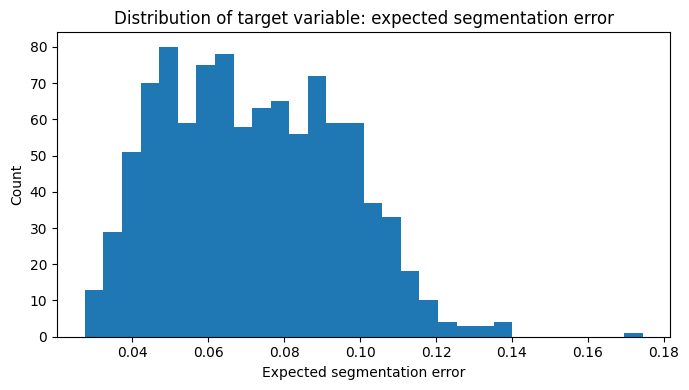

count    1000.000000
mean        0.071984
std         0.023123
min         0.027438
25%         0.052584
50%         0.070289
75%         0.090025
max         0.174409
Name: segmentation_abs_error, dtype: float64


In [54]:
# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.hist(y, bins=30)
plt.xlabel("Expected segmentation error")
plt.ylabel("Count")
plt.title("Distribution of target variable: expected segmentation error")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "target_segmentation_abs_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(y.describe())

In [55]:
# ------------------------------------------------------------
# Feature correlation with target
# ------------------------------------------------------------

correlations = (
    df[feature_columns + [target_column]]
    .corr(numeric_only=True)[target_column]
    .sort_values(ascending=False)
)

correlations

segmentation_abs_error        1.000000
relative_noise_drifted        0.807209
voxel_size_um                 0.684792
attenuation_contrast          0.173158
true_heterogeneity            0.165420
sample_thickness_mm           0.051624
true_porosity                 0.024736
voltage_kV                   -0.285328
true_mean_pore_diameter_um   -0.443498
filter_thickness_mm          -0.485535
current_uA                   -0.491820
pore_detectability           -0.670973
snr_drifted                  -0.677556
n_projections                -0.708006
exposure_ms                  -0.713325
detectability_score          -0.751169
cnr_drifted                  -0.783506
Name: segmentation_abs_error, dtype: float64

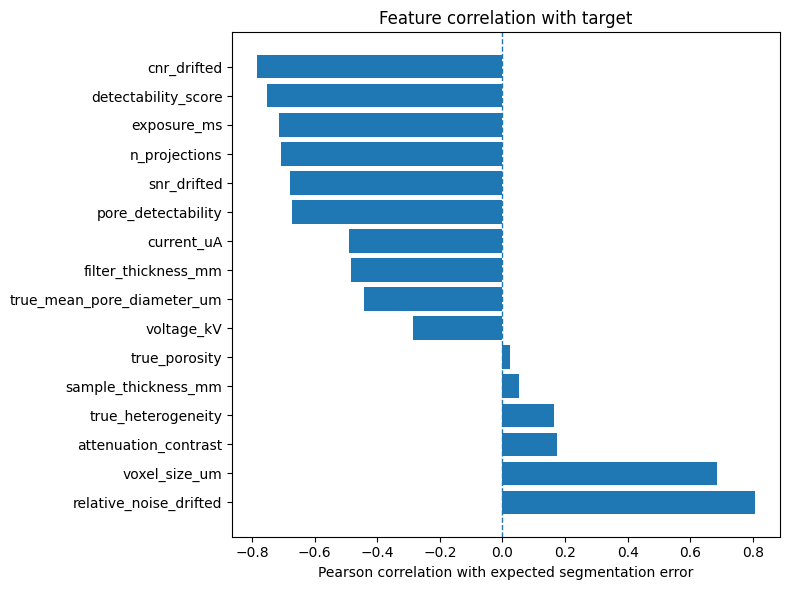

In [56]:
# ------------------------------------------------------------
# Plot feature correlations with target
# ------------------------------------------------------------

corr_without_target = correlations.drop(target_column)

plt.figure(figsize=(8, 6))
plt.barh(corr_without_target.index, corr_without_target.values)
plt.xlabel("Pearson correlation with expected segmentation error")
plt.title("Feature correlation with target")
plt.axvline(0, linestyle="--", linewidth=1)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "feature_correlation_with_segmentation_error.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [57]:
# ------------------------------------------------------------
# Train/test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_SEED
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (750, 16)
Test set: (250, 16)


In [58]:
def evaluate_regression_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Fit a regression model and return evaluation metrics.
    """
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    metrics = {
        "model": model_name,

        "train_MAE": mean_absolute_error(y_train, y_pred_train),
        "test_MAE": mean_absolute_error(y_test, y_pred_test),

        "train_RMSE": mean_squared_error(y_train, y_pred_train) ** 0.5,
        "test_RMSE": mean_squared_error(y_test, y_pred_test) ** 0.5,

        "train_R2": r2_score(y_train, y_pred_train),
        "test_R2": r2_score(y_test, y_pred_test),
    }

    return metrics, y_pred_test

In [59]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.0005, max_iter=10000))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
}

results = []
predictions = {}

for model_name, model in models.items():
    metrics, y_pred_test = evaluate_regression_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test,
        model_name
    )
    results.append(metrics)
    predictions[model_name] = y_pred_test

results_df = pd.DataFrame(results)
results_df

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,Linear Regression,0.002104,0.002112,0.003404,0.003824,0.977053,0.976358
1,Ridge Regression,0.002109,0.002115,0.003405,0.003829,0.977047,0.976286
2,Lasso Regression,0.002242,0.002271,0.003558,0.004007,0.974941,0.974032
3,Random Forest,0.002042,0.003312,0.003252,0.005326,0.979063,0.954124


In [60]:
results_path = RESULTS_DIR / "02_regression_model_comparison.csv"
results_df.to_csv(results_path, index=False)

print(f"Saved model comparison to: {results_path.resolve()}")

Saved model comparison to: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\02_regression_model_comparison.csv


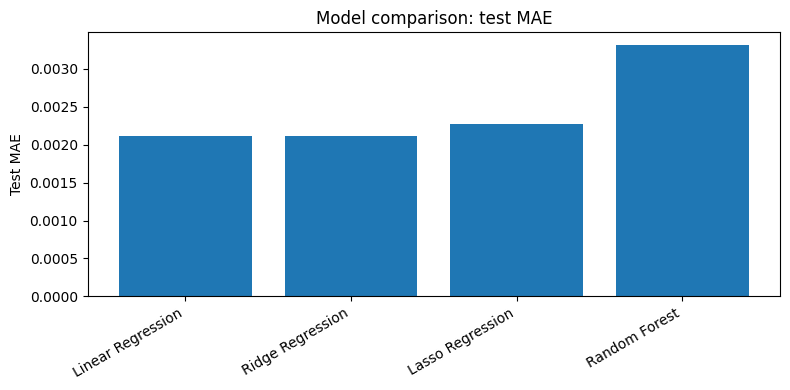

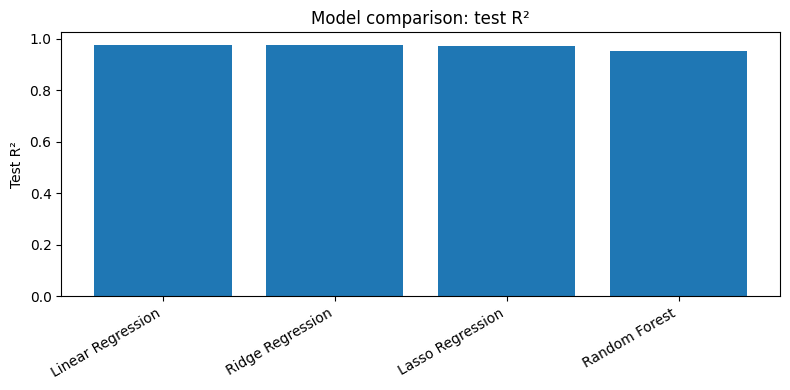

In [61]:
plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["test_MAE"])
plt.ylabel("Test MAE")
plt.title("Model comparison: test MAE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_test_mae.png", dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["test_R2"])
plt.ylabel("Test R²")
plt.title("Model comparison: test R²")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_test_r2.png", dpi=300, bbox_inches="tight")
plt.show()

In [62]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        return_train_score=True,
        n_jobs=-1
    )

    cv_results.append({
        "model": model_name,
        "cv_test_MAE_mean": -scores["test_MAE"].mean(),
        "cv_test_MAE_std": scores["test_MAE"].std(),
        "cv_test_RMSE_mean": -scores["test_RMSE"].mean(),
        "cv_test_RMSE_std": scores["test_RMSE"].std(),
        "cv_test_R2_mean": scores["test_R2"].mean(),
        "cv_test_R2_std": scores["test_R2"].std(),
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,model,cv_test_MAE_mean,cv_test_MAE_std,cv_test_RMSE_mean,cv_test_RMSE_std,cv_test_R2_mean,cv_test_R2_std
0,Linear Regression,0.002091,0.000124,0.003601,0.000549,0.974889,0.007747
1,Ridge Regression,0.002096,0.000122,0.003599,0.000548,0.974923,0.007676
2,Lasso Regression,0.002198,0.000123,0.003701,0.000564,0.973507,0.008035
3,Random Forest,0.003163,0.000097,0.004814,0.000475,0.955743,0.008882


In [63]:
cv_results_path = RESULTS_DIR / "02_cross_validation_results.csv"
cv_results_df.to_csv(cv_results_path, index=False)

print(f"Saved cross-validation results to: {cv_results_path.resolve()}")

Saved cross-validation results to: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\02_cross_validation_results.csv


In [64]:
best_model_name = results_df.sort_values("test_MAE").iloc[0]["model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
best_predictions = best_model.predict(X_test)

print("Best model:", best_model_name)
results_df.sort_values("test_MAE")

Best model: Linear Regression


,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,Linear Regression,0.002104,0.002112,0.003404,0.003824,0.977053,0.976358
1,Ridge Regression,0.002109,0.002115,0.003405,0.003829,0.977047,0.976286
2,Lasso Regression,0.002242,0.002271,0.003558,0.004007,0.974941,0.974032
3,Random Forest,0.002042,0.003312,0.003252,0.005326,0.979063,0.954124


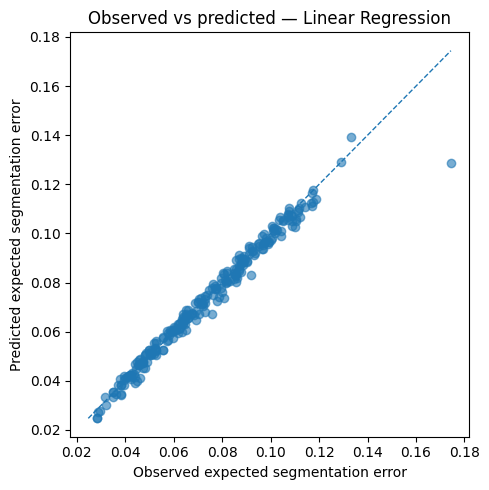

In [65]:
# ------------------------------------------------------------
# Observed vs predicted values
# ------------------------------------------------------------

plt.figure(figsize=(5, 5))
plt.scatter(y_test, best_predictions, alpha=0.6)

min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=1
)

plt.xlabel("Observed expected segmentation error")
plt.ylabel("Predicted expected segmentation error")
plt.title(f"Observed vs predicted — {best_model_name}")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "observed_vs_predicted_segmentation_error.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

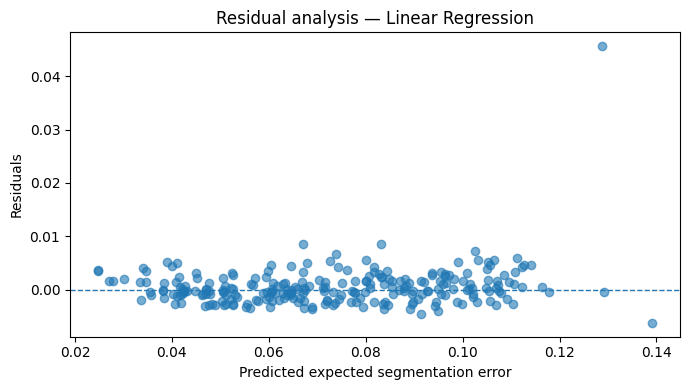

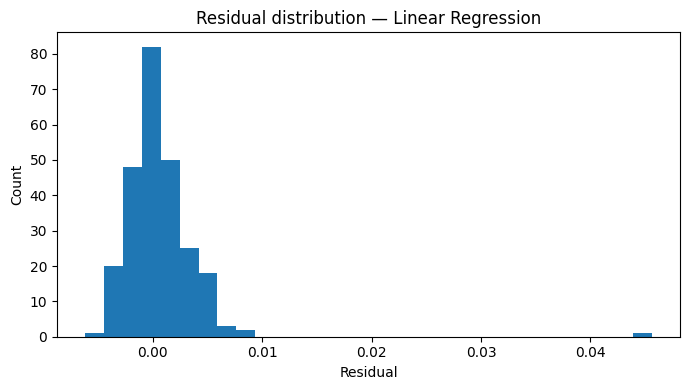

Residual summary:
count    250.000000
mean       0.000560
std        0.003790
min       -0.006183
25%       -0.001409
50%        0.000026
75%        0.001710
max        0.045594
Name: segmentation_abs_error, dtype: float64


In [66]:
# ------------------------------------------------------------
# Residual analysis
# ------------------------------------------------------------

residuals = y_test - best_predictions

plt.figure(figsize=(7, 4))
plt.scatter(best_predictions, residuals, alpha=0.6)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Predicted expected segmentation error")
plt.ylabel("Residuals")
plt.title(f"Residual analysis — {best_model_name}")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "residuals_vs_predictions_segmentation_error.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title(f"Residual distribution — {best_model_name}")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "residual_distribution_segmentation_error.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Residual summary:")
print(pd.Series(residuals).describe())

In [67]:
# ------------------------------------------------------------
# Residuals by acquisition protocol
# ------------------------------------------------------------

test_results = X_test.copy()
test_results["observed_segmentation_error"] = y_test.values
test_results["predicted_segmentation_error"] = best_predictions
test_results["residual"] = residuals.values

# Recover protocol and outlier information from the original dataframe
test_results["protocol"] = df.loc[X_test.index, "protocol"].values
test_results["is_outlier"] = df.loc[X_test.index, "is_outlier"].values

protocol_error_summary = (
    test_results
    .groupby("protocol")
    .agg(
        n=("observed_segmentation_error", "count"),
        observed_error_mean=("observed_segmentation_error", "mean"),
        predicted_error_mean=("predicted_segmentation_error", "mean"),
        residual_mean=("residual", "mean"),
        residual_std=("residual", "std"),
        outlier_rate=("is_outlier", "mean")
    )
    .round(5)
)

protocol_error_summary

,n,observed_error_mean,predicted_error_mean,residual_mean,residual_std,outlier_rate
protocol,,,,,,
A_standard,139,0.09025,0.0891,0.00115,0.00463,0.01439
B_optimized,111,0.05243,0.0526,-0.00017,0.00214,0.00000


C:\Users\Peter\AppData\Local\Temp\ipykernel_22288\4131286107.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(residual_data, labels=protocols)


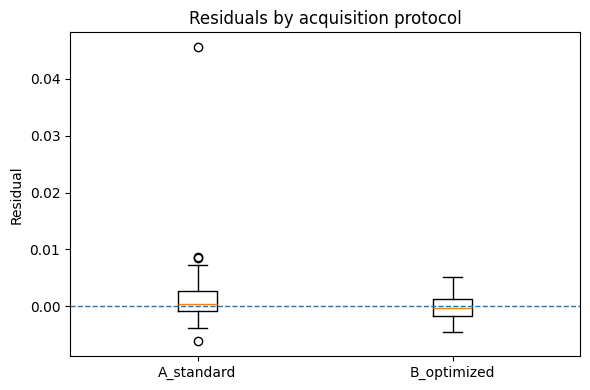

In [68]:
# ------------------------------------------------------------
# Residual distribution by protocol
# ------------------------------------------------------------

protocols = ["A_standard", "B_optimized"]

residual_data = [
    test_results.loc[test_results["protocol"] == protocol, "residual"]
    for protocol in protocols
]

plt.figure(figsize=(6, 4))
plt.boxplot(residual_data, labels=protocols)
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Residual")
plt.title("Residuals by acquisition protocol")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "residuals_by_protocol_segmentation_error.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [69]:
# ------------------------------------------------------------
# Random Forest feature importance
# ------------------------------------------------------------

rf_model = models["Random Forest"]
rf_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
13,cnr_drifted,0.450727
11,relative_noise_drifted,0.227352
15,detectability_score,0.142649
14,pore_detectability,0.122359
8,true_heterogeneity,0.033574
7,true_mean_pore_diameter_um,0.007954
2,exposure_ms,0.005327
12,snr_drifted,0.002885
4,voxel_size_um,0.001126
5,filter_thickness_mm,0.001122


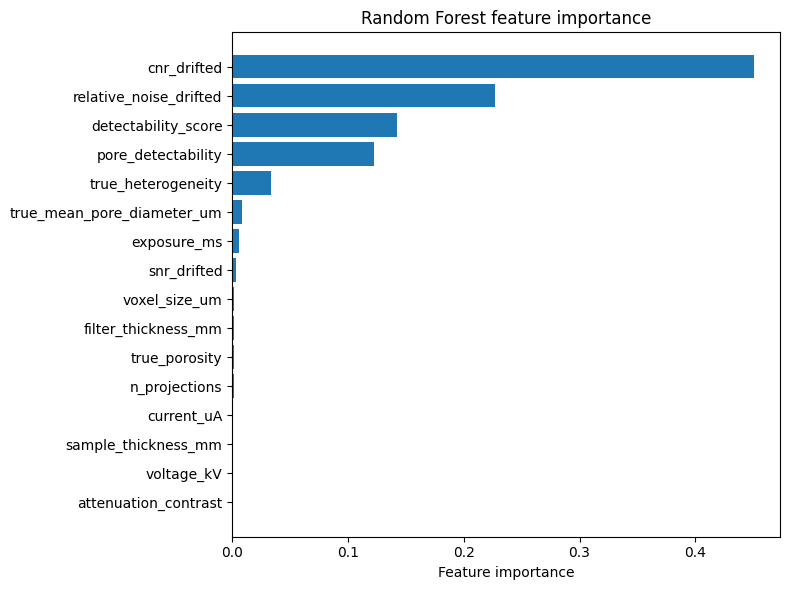

In [70]:
# ------------------------------------------------------------
# Plot Random Forest feature importance
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Feature importance")
plt.title("Random Forest feature importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "random_forest_feature_importance_segmentation_error.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [71]:
# ------------------------------------------------------------
# Ridge regression coefficients
# ------------------------------------------------------------

ridge_model = models["Ridge Regression"]
ridge_model.fit(X_train, y_train)

ridge_coefficients = ridge_model.named_steps["model"].coef_

ridge_coef_df = pd.DataFrame({
    "feature": feature_columns,
    "standardized_coefficient": ridge_coefficients
}).sort_values(
    "standardized_coefficient",
    key=np.abs,
    ascending=False
)

ridge_coef_df

,feature,standardized_coefficient
15,detectability_score,-0.012505
11,relative_noise_drifted,0.011047
8,true_heterogeneity,0.005002
13,cnr_drifted,-0.003126
6,true_porosity,0.001300
12,snr_drifted,-0.001193
9,sample_thickness_mm,-0.000264
3,n_projections,0.000240
7,true_mean_pore_diameter_um,0.000231
10,attenuation_contrast,-0.000226


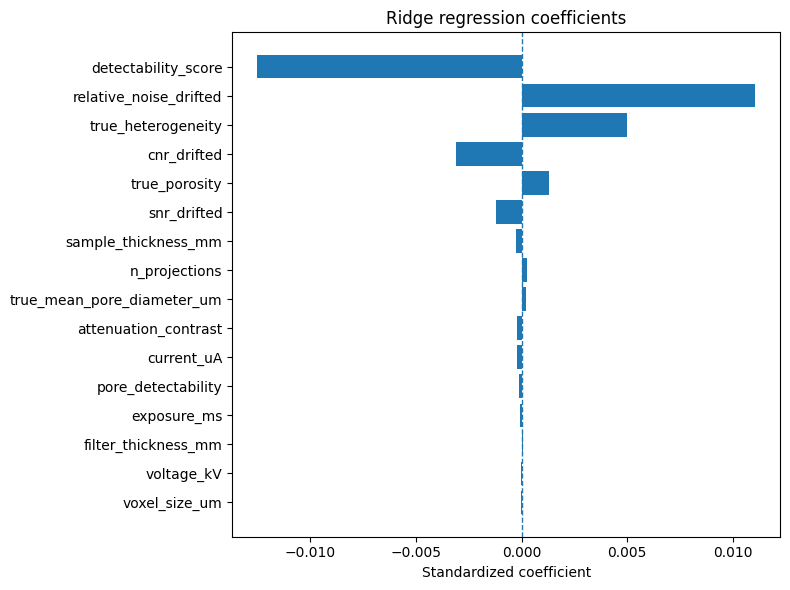

In [72]:
# ------------------------------------------------------------
# Plot Ridge standardized coefficients
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))
plt.barh(
    ridge_coef_df["feature"],
    ridge_coef_df["standardized_coefficient"]
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Standardized coefficient")
plt.title("Ridge regression coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "ridge_standardized_coefficients_segmentation_error.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [73]:
# ------------------------------------------------------------
# Save final outputs
# ------------------------------------------------------------

feature_importance_path = RESULTS_DIR / "02_random_forest_feature_importance_segmentation_error.csv"
ridge_coef_path = RESULTS_DIR / "02_ridge_coefficients_segmentation_error.csv"
test_predictions_path = RESULTS_DIR / "02_test_predictions_segmentation_error.csv"
model_comparison_path = RESULTS_DIR / "02_regression_model_comparison_segmentation_error.csv"

feature_importance.to_csv(feature_importance_path, index=False)
ridge_coef_df.to_csv(ridge_coef_path, index=False)
test_results.to_csv(test_predictions_path, index=False)
results_df.to_csv(model_comparison_path, index=False)

print("Saved:")
print(feature_importance_path.resolve())
print(ridge_coef_path.resolve())
print(test_predictions_path.resolve())
print(model_comparison_path.resolve())

Saved:
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\02_random_forest_feature_importance_segmentation_error.csv
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\02_ridge_coefficients_segmentation_error.csv
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\02_test_predictions_segmentation_error.csv
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\02_regression_model_comparison_segmentation_error.csv


In [74]:
# ------------------------------------------------------------
# Notebook completion summary
# ------------------------------------------------------------

print("Regression and model validation notebook completed.")
print()
print("Target variable:")
print(f"- {target_column}")
print()
print("Models evaluated:")
for model_name in models:
    print(f"- {model_name}")
print()
print("Best model based on test MAE:")
print(f"- {best_model_name}")
print()
print("Best model performance:")
best_row = results_df.loc[results_df["model"] == best_model_name].iloc[0]
print(f"- Test MAE:  {best_row['test_MAE']:.6f}")
print(f"- Test RMSE: {best_row['test_RMSE']:.6f}")
print(f"- Test R²:   {best_row['test_R2']:.4f}")
print()
print("Main validation outputs:")
print("- Train/test model comparison")
print("- 5-fold cross-validation")
print("- Observed vs predicted plot")
print("- Residual analysis")
print("- Residuals by acquisition protocol")
print("- Random Forest feature importance")
print("- Ridge standardized coefficients")

Regression and model validation notebook completed.

Target variable:
- segmentation_abs_error

Models evaluated:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest

Best model based on test MAE:
- Linear Regression

Best model performance:
- Test MAE:  0.002112
- Test RMSE: 0.003824
- Test R²:   0.9764

Main validation outputs:
- Train/test model comparison
- 5-fold cross-validation
- Observed vs predicted plot
- Residual analysis
- Residuals by acquisition protocol
- Random Forest feature importance
- Ridge standardized coefficients
